# Mixed Naive Bayes Classifier

## Problem Description
The goal of this project is to predict the **credit risk grade** assigned by LendingClub.  
The target variable takes one of the following values:

$$
\text{grade} \in \{A, B, C, D, E, F, G\}
\quad \Rightarrow \quad
\text{grade\_idx} \in \{0, 1, 2, 3, 4, 5, 6\}
$$

This makes the task a **multiclass classification problem** with **7 possible classes**.

---

## Feature distribution

In our dataset, we have a mix of **numerical** and **categorical** variables, so a single distribution is not sufficient.  
For this reason, we use a **Mixed Naive Bayes** approach.

---

## Feature Modeling

### Continuous Features (Gaussian Naive Bayes)

Numerical features such as `loan_amnt`, `dti`, and `fico_avg` are modeled using a **Gaussian distribution**.  
For each feature $j$ and class $k$, we estimate the class-specific mean $\mu_{kj}$ and variance $\sigma^2_{kj}$.


The likelihood is given by:

$$
P(x_j \mid C_k)
=
\frac{1}{\sqrt{2\pi\sigma^2_{kj}}}
\exp\left(
-\frac{(x_j - \mu_{kj})^2}{2\sigma^2_{kj}}
\right)
$$

---

### Categorical Features (Categorical Naive Bayes)

Categorical features such as `purpose` and `home_ownership` are modeled using a **categorical distribution**.  
The probabilities are estimated from frequency counts in the training data.

To avoid zero probabilities for unseen categories, **Laplace smoothing** is applied:

$$
P(x_j \mid C_k)
=
\frac{\text{count}(x_j, C_k) + \alpha}
     {\text{count}(C_k) + \alpha \cdot |V_j|}
$$

where:
- $\alpha = 1.0$ is the smoothing parameter  
- $|V_j|$ is the number of unique categories for feature $j$


---

## Prediction Rule

Given a new data point \( x \), we compute the posterior score for each class.  
Instead of multiplying probabilities directly, we work with **log-probabilities** to prevent numerical underflow.

The predicted class is the one with the highest log-posterior value:

$$
\hat{y}
=
\underset{k \in \{0,\dots,6\}}{\arg\max}
\left(
\log P(C_k)
+
\sum_{j \in \text{continuous}} \log P(x_j \mid C_k)
+
\sum_{j \in \text{categorical}} \log P(x_j \mid C_k)
\right)
$$

---

Overall, this mixed approach allows us to handle different feature types in a principled way while keeping the model simple and interpretable.


Mount Drive + Imports + Paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
DATA_ROOT = Path("/content/drive/MyDrive/ML Project/Data")
TRAIN_DIR = DATA_ROOT / "Train"
TEST_DIR  = DATA_ROOT / "Test"

train_csv = TRAIN_DIR / "train.csv"
dev_csv   = TRAIN_DIR / "dev.csv"
test_csv  = TEST_DIR  / "test.csv"

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists:", TEST_DIR.exists())

print("Train CSV exists:", train_csv.exists(), train_csv)
print("Dev CSV exists:", dev_csv.exists(), dev_csv)
print("Test CSV exists:", test_csv.exists(), test_csv)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_ROOT exists: True
TRAIN_DIR exists: True
TEST_DIR exists: True
Train CSV exists: True /content/drive/MyDrive/ML Project/Data/Train/train.csv
Dev CSV exists: True /content/drive/MyDrive/ML Project/Data/Train/dev.csv
Test CSV exists: True /content/drive/MyDrive/ML Project/Data/Test/test.csv


## Load train / dev / test data

We read the CSV files from Google Drive and do basic sanity checks:
- shape
- column names
- class distribution (grade_idx)


In [ ]:
train_df = pd.read_csv(train_csv)
dev_df   = pd.read_csv(dev_csv)
test_df  = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:", list(train_df.columns))

# Basic check: target column exists
assert "grade_idx" in train_df.columns, "Expected 'grade_idx' in train.csv"
assert "grade_idx" in dev_df.columns, "Expected 'grade_idx' in dev.csv"
assert "grade_idx" in test_df.columns, "Expected 'grade_idx' in test.csv"

# Class distribution
print("\nTrain grade_idx counts:\n", train_df["grade_idx"].value_counts().sort_index())
print("\nDev grade_idx counts:\n", dev_df["grade_idx"].value_counts().sort_index())
print("\nTest grade_idx counts:\n", test_df["grade_idx"].value_counts().sort_index())

train_df.head()


Train shape: (59619, 24)
Dev shape: (12775, 24)
Test shape: (12782, 24)

Columns: ['grade', 'grade_idx', 'purpose', 'home_ownership', 'verification_status', 'addr_state', 'loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']

Train grade_idx counts:
 grade_idx
0    8517
1    8517
2    8517
3    8517
4    8517
5    8517
6    8517
Name: count, dtype: int64

Dev grade_idx counts:
 grade_idx
0    1825
1    1825
2    1825
3    1825
4    1825
5    1825
6    1825
Name: count, dtype: int64

Test grade_idx counts:
 grade_idx
0    1826
1    1826
2    1826
3    1826
4    1826
5    1826
6    1826
Name: count, dtype: int64


,grade,grade_idx,purpose,home_ownership,verification_status,addr_state,loan_amnt,term,emp_length,annual_inc,...,total_acc,pub_rec,revol_bal,revol_util,collections_12_mths_ex_med,acc_now_delinq,pub_rec_bankruptcies,tax_liens,credit_history_months,fico_avg
0,D,3,credit_card,RENT,Verified,CA,6000.0,36.0,10.0,65000.0,...,55.0,1.0,1363.0,3.6,0.0,0.0,1.0,0.0,218.020534,677.0
1,G,6,small_business,MORTGAGE,Source Verified,OH,14600.0,36.0,3.0,60000.0,...,11.0,0.0,6995.0,88.5,0.0,0.0,0.0,0.0,259.055441,667.0
2,G,6,debt_consolidation,MORTGAGE,Source Verified,CA,35000.0,36.0,10.0,184000.0,...,22.0,1.0,37361.0,62.7,0.0,0.0,0.0,1.0,128.985626,682.0
3,E,4,debt_consolidation,RENT,Source Verified,IL,15000.0,60.0,2.0,30000.0,...,38.0,0.0,13211.0,63.5,0.0,0.0,0.0,0.0,132.008214,672.0
4,E,4,debt_consolidation,RENT,Verified,MD,15200.0,60.0,4.0,38000.0,...,10.0,0.0,5600.0,70.0,0.0,0.0,0.0,0.0,223.934292,697.0


## Log transform highly skewed numeric features

Some financial variables are heavy-tailed (very large outliers).
We apply log1p(x) = log(1 + x) to compress large values and stabilize SGD training.


Then we set up the modeling inputs:
- Define categorical columns: `purpose`, `home_ownership`, `verification_status`
- Add `addr_state` to `drop_cols` so it is **removed from the dataset later** (along with the label columns).
- Treat everything else (not dropped and not categorical) as **continuous**.
- Build `X_train/X_dev/X_test` and `y_train/y_dev/y_test`, and also store index lists (`cont_indices`, `cat_indices`) for later use.

In [ ]:
# Log Transform for Skewed Numeric Features
all_cols = train_df.columns.tolist()
# Exclude target and categorical features from skewness check
# We exclude 'addr_state'
exclude_cols = ['grade_idx', 'grade', 'purpose', 'home_ownership', 'verification_status', 'addr_state']
numeric_candidates = [c for c in all_cols if c not in exclude_cols]

skewness = train_df[numeric_candidates].skew(numeric_only=True).sort_values(ascending=False)
AUTO_SKEWED = skewness[skewness > 1.5].index.tolist()

print(f"Applying log1p transform to skewed features: {AUTO_SKEWED}")

for c in AUTO_SKEWED:
    if (train_df[c] >= 0).all() and (dev_df[c] >= 0).all() and (test_df[c] >= 0).all():
        train_df[c] = np.log1p(train_df[c])
        dev_df[c]   = np.log1p(dev_df[c])
        test_df[c]  = np.log1p(test_df[c])

# Define Feature Groups

# Removed 'addr_state' from this list
categorical_names = ['purpose', 'home_ownership', 'verification_status']

# Added 'addr_state' to drop_cols so it is completely removed from the dataset
# We check if 'grade' exists to avoid errors if run multiple times
base_drop = [target_col, 'addr_state']
if 'grade' in train_df.columns:
    base_drop.append('grade')

# Ensure we only drop columns that actually exist
drop_cols = [c for c in base_drop if c in train_df.columns]

# Identify Continuous Features
# All features remaining in the dataframe (except categoricals) are treated as continuous
all_features_in_df = [c for c in train_df.columns if c not in drop_cols]
continuous_names = [c for c in all_features_in_df if c not in categorical_names]

# Prepare Matrices (Train, Dev, Test)
# Train
X_train_df = train_df.drop(columns=drop_cols)
y_train = train_df[target_col].values

# Dev
X_dev_df = dev_df.drop(columns=drop_cols)
y_dev = dev_df[target_col].values

# Test
X_test_df = test_df.drop(columns=drop_cols)
y_test = test_df[target_col].values

# Get integer indices for the algorithm
cont_indices = [X_train_df.columns.get_loc(c) for c in continuous_names]
cat_indices = [X_train_df.columns.get_loc(c) for c in categorical_names]

# Convert to Numpy Arrays
X_train = X_train_df.values
X_dev   = X_dev_df.values
X_test  = X_test_df.values

print("-" * 30)
print(f"Continuous Features ({len(continuous_names)}): {continuous_names}")
print(f"Categorical Features ({len(categorical_names)}): {categorical_names}")
print(f"Dropped Features: {drop_cols}")

Applying log1p transform to skewed features: ['annual_inc', 'revol_bal', 'dti', 'acc_now_delinq', 'tax_liens', 'collections_12_mths_ex_med', 'delinq_2yrs', 'pub_rec', 'pub_rec_bankruptcies', 'inq_last_6mths']
------------------------------
Continuous Features (18): ['loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']
Categorical Features (3): ['purpose', 'home_ownership', 'verification_status']
Dropped Features: ['grade_idx', 'addr_state', 'grade']


Mixed Naive Bayes Implementation

Dataset contains categorical variables; we model them with categorical conditional probabilities, and continuous variables with class-conditional Gaussians (diagonal covariance). No binarization is used.

In [ ]:
class MixedNaiveBayes:
    def __init__(self, continuous_idx, categorical_idx, alpha=1.0):
        self.cont_idx = continuous_idx
        self.cat_idx = categorical_idx
        self.alpha = alpha  # Laplace smoothing
        self.classes = None
        self.priors = {}
        self.gauss_params = {}
        self.cat_params = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples = X.shape[0]

        for c in self.classes:
            X_c = X[y == c]

            # Prior
            self.priors[c] = X_c.shape[0] / n_samples

            # Gaussian Parameters
            self.gauss_params[c] = {
                'mean': np.mean(X_c[:, self.cont_idx].astype(float), axis=0),
                'var': np.var(X_c[:, self.cont_idx].astype(float), axis=0) + 1e-9
            }

            # Categorical Parameters
            self.cat_params[c] = {}
            for idx in self.cat_idx:
                unique_vals = np.unique(X[:, idx])
                counts = {val: np.sum(X_c[:, idx] == val) for val in unique_vals}
                total = X_c.shape[0]
                probs = {val: (count + self.alpha) / (total + self.alpha * len(unique_vals))
                         for val, count in counts.items()}
                self.cat_params[c][idx] = probs

    def predict(self, X):
        predictions = []
        for x in X:
            scores = []
            for c in self.classes:
                s = np.log(self.priors[c])

                # Gaussian Log-Likelihood
                if len(self.cont_idx) > 0:
                    m = self.gauss_params[c]['mean']
                    v = self.gauss_params[c]['var']
                    xc = x[self.cont_idx].astype(float)
                    s += np.sum(-0.5 * np.log(2 * np.pi * v) - ((xc - m)**2 / (2 * v)))

                # Categorical Log-Likelihood
                for idx in self.cat_idx:
                    val = x[idx]
                    prob = self.cat_params[c][idx].get(val, 1e-9)
                    s += np.log(prob)

                scores.append(s)
            predictions.append(self.classes[np.argmax(scores)])
        return np.array(predictions)

Execution & Evaluation

In [ ]:
# Training
print("Training Mixed Naive Bayes...")
mnb = MixedNaiveBayes(cont_indices, cat_indices)
mnb.fit(X_train, y_train)

# Prediction on All Sets
print("Predicting on Train, Dev, and Test sets...")
y_train_pred = mnb.predict(X_train)
y_dev_pred   = mnb.predict(X_dev)
y_test_pred  = mnb.predict(X_test)

# Accuracy Calculation
train_acc = np.mean(y_train_pred == y_train)
dev_acc   = np.mean(y_dev_pred == y_dev)
test_acc  = np.mean(y_test_pred == y_test)

print("\n" + "="*40)
print(f"RESULTS: Mixed Naive Bayes")
print("="*40)
print(f"Train Accuracy: {train_acc:.4f} ({train_acc * 100:.2f}%)")
print(f"Dev Accuracy:   {dev_acc:.4f} ({dev_acc * 100:.2f}%)")
print(f"Test Accuracy:  {test_acc:.4f} ({test_acc * 100:.2f}%)")
print("-" * 40)



Training Mixed Naive Bayes...
Predicting on Train, Dev, and Test sets...

RESULTS: Mixed Naive Bayes
Train Accuracy: 0.3072 (30.72%)
Dev Accuracy:   0.3033 (30.33%)
Test Accuracy:  0.3037 (30.37%)
----------------------------------------


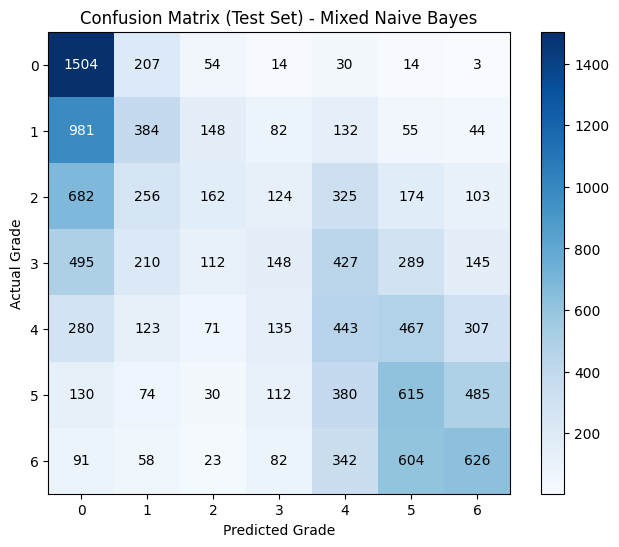

In [ ]:
# Confusion Matrix Visualization (Test Set)
cm = pd.crosstab(y_test, y_test_pred, rownames=['Actual'], colnames=['Predicted'])
cm_values = cm.values
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm_values, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Test Set) - Mixed Naive Bayes')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
plt.xlabel('Predicted Grade')
plt.ylabel('Actual Grade')

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(cm_values[i, j]),
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if cm_values[i, j] > cm_values.max() / 2 else "black")

plt.show()

Interpretation of Naive Bayes Results

The Mixed Naive Bayes classifier achieved an accuracy of 30.32% on the test set. Given that this is a 7-class classification problem with balanced classes (random guessing would yield ~14.3%), the model performs significantly better than chance, indicating it has successfully learned patterns in the data.

Looking at the Confusion Matrix, we observe that the errors are not random, they are concentrated along the diagonal. This means that when the model misclassifies a loan, it usually assigns it to a neighboring grade (e.g., predicting Grade B instead of A, or E instead of F). The model rarely confuses low-risk loans (Grade A) with high-risk ones (Grade G).

However, the accuracy is limited compared to more complex models. This is likely due to the "naive" assumption of feature independence, which rarely holds in financial data (e.g., interest rate is highly correlated with FICO score and loan amount). Despite the Gaussian and Categorical likelihoods capturing the general distribution of features, the model struggles to distinguish the fine decision boundaries between adjacent risk grades.

Visualization of Learned Gaussian Distributions

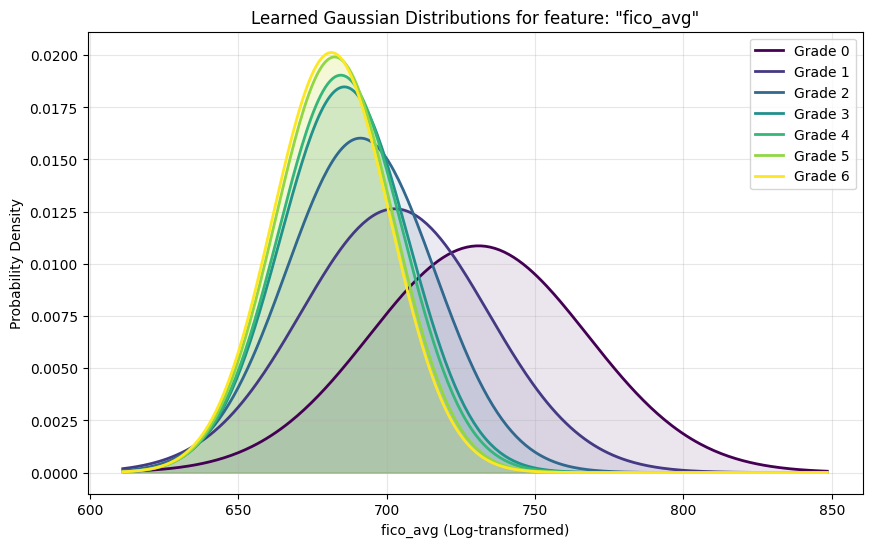

In [ ]:
# Gaussian Distribution Visualization
def plot_gaussian_distributions(model, feature_name, X_df, cont_names):
    if feature_name not in cont_names:
        print(f"Feature '{feature_name}' not found.")
        return

    feat_idx_in_cont = cont_names.index(feature_name)
    plt.figure(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(model.classes)))

    col_data = X_df[feature_name]
    x_min, x_max = col_data.min(), col_data.max()
    x_axis = np.linspace(x_min - 1, x_max + 1, 300)

    for i, c in enumerate(model.classes):
        mean = model.gauss_params[c]['mean'][feat_idx_in_cont]
        var = model.gauss_params[c]['var'][feat_idx_in_cont]
        std = np.sqrt(var)
        pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_axis - mean) / std) ** 2)

        plt.plot(x_axis, pdf, label=f'Grade {c}', color=colors[i], linewidth=2)
        plt.fill_between(x_axis, pdf, alpha=0.1, color=colors[i])

    plt.title(f'Learned Gaussian Distributions for feature: "{feature_name}"')
    plt.xlabel(f'{feature_name} (Log-transformed)')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Example: Plot FICO Score distribution
target_feature = 'fico_avg'
if target_feature in continuous_names:
    plot_gaussian_distributions(mnb, target_feature, X_train_df, continuous_names)